# Assignment DSC400 3.2

**Author:** Yisrael Wasserman  
**Date:** September 25, 2026  
**Description:** Exploring customer_insights.csv

In [1]:
import pandas as pd 

In [2]:
#Import the data
df = pd.read_csv('customer_insights.csv')

In [3]:
# Explore the data: 
df.head()

,CustomerID,Age,SpendCategory,TransactionAmount,ProductCategory
0,90166,65,High,484.396933,Electronics
1,41361,49,Low,185.815288,Electronics
2,96044,47,Medium,178.332958,Electronics
3,87539,19,Medium,444.878793,Clothing
4,70709,25,Low,807.684483,Home


Notes:
- I am not sure what `SpendCategory` defines. As you can see in row 4, the `TransactionAmount` is 807$ and it has a `SpendCategory` of "Low," while other rows have much lower transaction amounts but are in "Medium" or "High."
- Everything else looks all right.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   SpendCategory      10000 non-null  str    
 3   TransactionAmount  10000 non-null  float64
 4   ProductCategory    10000 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 390.8 KB


- No null values.
- All data types look correct.


In [5]:
df.describe()

,CustomerID,Age,TransactionAmount
count,10000.000000,10000.000000,10000.000000
mean,54942.155300,43.650600,403.034919
std,25945.926887,14.970756,284.507334
min,10002.000000,18.000000,1.287571
25%,32453.000000,31.000000,194.324808
50%,55142.500000,44.000000,338.779355
75%,77117.000000,57.000000,544.877547
max,99997.000000,69.000000,2537.036820


- The numeric ranges look reasonable overall.
- Age range is 18–69.
- Transaction amounts range from about 1.29  to 2,537.04
- The maximum is much higher than the 75th percentile, so I will check for possible outliers below.
- `CustomerID` ranges from 10002 to 99997. Since there are only 10,000 rows, the IDs are not sequential, meaning they do not simply increase by 1 for each new customer.


## Data Cleaning and Anomaly Check

Before analyzing the data, I want to check for missing values, duplicate rows, and inconsistent category formatting.


In [29]:
# Check for duplicate rows

print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


- `df.info()` already showed that there are no missing values, so no missing-value replacement or removal is needed.
- I also check for exact duplicate rows.
- Next, I will check whether unusually large transaction amounts could affect the analysis.


In [7]:
# Use the IQR method to identify unusually high or low transaction amounts
q1 = df["TransactionAmount"].quantile(0.25)
q3 = df["TransactionAmount"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["TransactionAmount"] < lower_bound) |
    (df["TransactionAmount"] > upper_bound)
]

print(f"IQR: {iqr:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of statistical outliers: {len(outliers)}")

outliers.sort_values("TransactionAmount", ascending=False).head()


IQR: 350.55
Lower bound: -331.50
Upper bound: 1070.71
Number of statistical outliers: 311


,CustomerID,Age,SpendCategory,TransactionAmount,ProductCategory
3317,94141,46,Medium,2537.036820,Beauty
7771,30053,45,Medium,2258.434228,Home
7811,12899,65,Low,2234.450689,Home
4695,13751,31,Medium,2041.732105,Beauty
4427,33415,39,Low,2003.024287,Clothing


The IQR method flags unusually large or small values statistically, but an outlier is not automatically a data error. Because the transaction amounts are positive and there is no evidence in this dataset that the large purchases are invalid, I will **keep the outliers** rather than remove valid customer transactions. I will make them visible in the charts so they do not go unnoticed.


In [8]:
# See each product category

all_categories = df['ProductCategory'].unique()
all_categories


<StringArray>
['Electronics', 'Clothing', 'Home', 'Beauty']
Length: 4, dtype: str

- Looks good. There are only four categories.


In [9]:
# See if there are any repeat customers

print(f"There are {df['CustomerID'].nunique()} unique Customer IDs out of {df['CustomerID'].count()} total entries.")


There are 9473 unique Customer IDs out of 10000 total entries.


- That means there are some repeat customers.
- I think it will be interesting to visualize the number of repeat customers and how many times they returned.
- Note that repeat customers are a very small part of the business.


- There aren't that many.


## Understanding SpendCategory - groupby()

I saw above that `SpendCategory` does not seem to be correlated with `TransactionAmount`. I want to find out if that is an error or if it is calculated in some other way.


In [10]:
df.groupby("SpendCategory")["TransactionAmount"].describe()

,count,mean,std,min,25%,50%,75%,max
SpendCategory,,,,,,,,
High,3291.0,400.718294,284.685283,1.409882,193.586438,331.396779,547.008171,1916.639218
Low,3326.0,403.505778,277.048102,4.883557,195.281060,344.718371,549.229196,2234.450689
Medium,3383.0,404.825619,291.553231,1.287571,193.631383,337.909176,536.712382,2537.036820


- The transaction-amount distributions for the three `SpendCategory` groups look very similar. Their means are all around $400, and their ranges overlap heavily.
- This suggests that `SpendCategory` is **not based directly on the current transaction amount**.
- Without documentation explaining how `SpendCategory` was created, I cannot conclude that it is miscalculated; it may represent another customer attribute or classification.


# Visualization


There are three topics I want to investigate:
1. What does the overall transaction distribution look like, including possible outliers?
2. Does `SpendCategory` appear to be based on transaction amount, product category, or age?
3. What are the habits of returning customers? How much do they spend, and how many times did they return?


## All Transactions vs age: 

I will start by plotting every transaction. I want to get an idea of the outliers and also of the distrubution. 


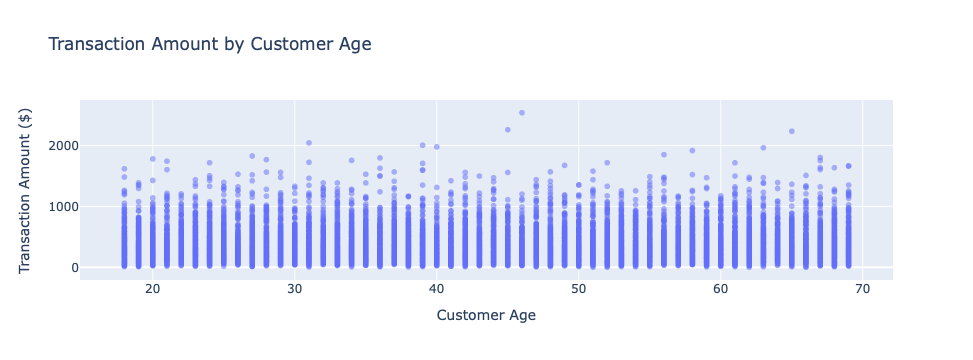

In [31]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Age",
    y="TransactionAmount",
    title="Transaction Amount by Customer Age",
    labels={
        "Age": "Customer Age",
        "TransactionAmount": "Transaction Amount ($)"
    },

    opacity=0.5
)

fig.show()

## SpendCategory

Let's visualize `SpendCategory`:

1. `SpendCategory` for each `ProductCategory` and each age range.
2. Each `SpendCategory` on its own chart to see its distribution. Based on the `describe()` results above, I am guessing they will all look similar because their means and ranges are similar, but I want to double-check.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

### Let's see the distribution for each SpendCategory


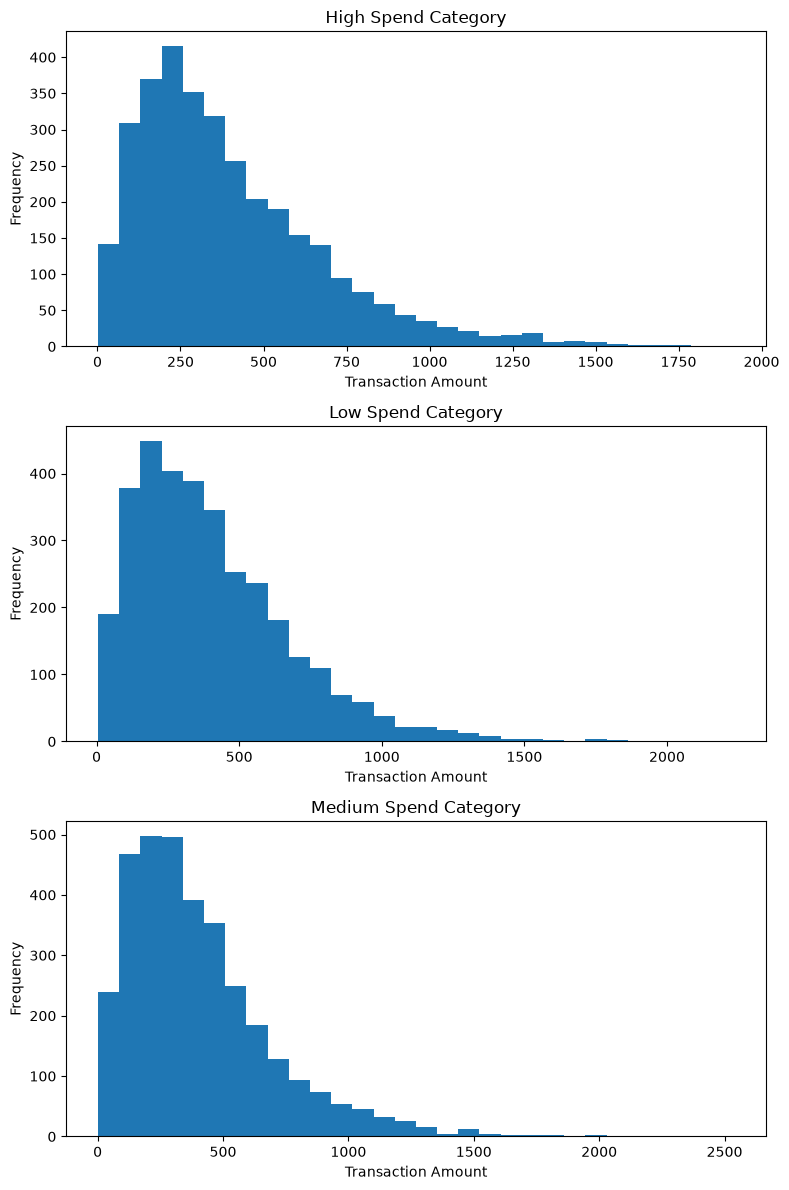

In [15]:
categories = df["SpendCategory"].unique()

fig, axes = plt.subplots(
    len(categories),
    1,
    figsize=(8, 4 * len(categories))
)

for ax, category in zip(axes, categories):

    category_data = df.loc[
        df["SpendCategory"] == category,
        "TransactionAmount"
    ]

    ax.hist(category_data, bins=30)

    ax.set_title(f"{category} Spend Category")
    ax.set_xlabel("Transaction Amount")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### It seems that the distributions are almost the same for all SpendCategories.

- Let's see whether `SpendCategory` is based on `ProductCategory`, meaning that each product category has unique spending categories.


In [16]:


product_spend = (
    df.groupby(["ProductCategory", "SpendCategory"])["TransactionAmount"]
      .mean()
      .reset_index()
)

product_spend

,ProductCategory,SpendCategory,TransactionAmount
0,Beauty,High,399.179398
1,Beauty,Low,402.468022
2,Beauty,Medium,394.282708
3,Clothing,High,377.721403
4,Clothing,Low,406.408149
5,Clothing,Medium,426.898940
6,Electronics,High,419.703551
7,Electronics,Low,399.544422
8,Electronics,Medium,399.727772
9,Home,High,405.497472


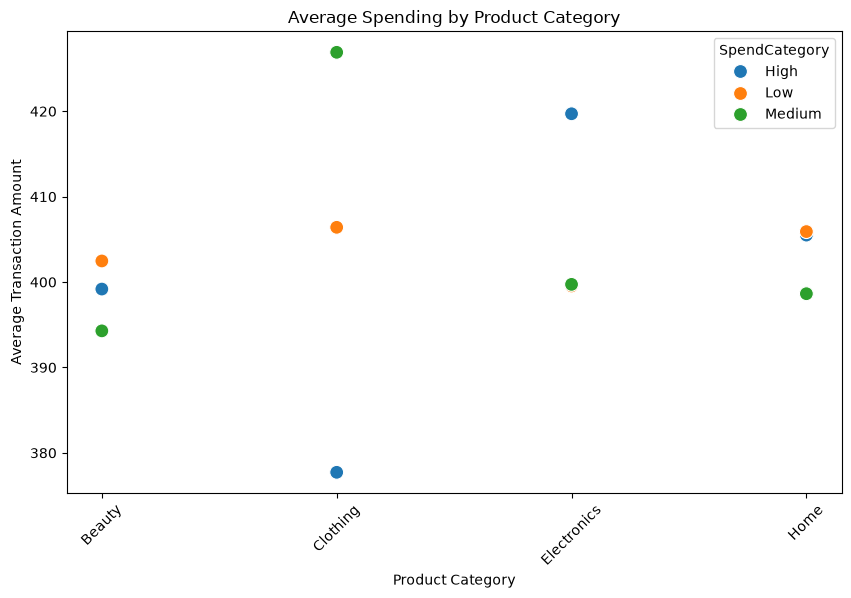

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_spend,
    x="ProductCategory",
    y="TransactionAmount",
    hue="SpendCategory",
    s=100
)

plt.title("Average Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=45)

plt.show()

### `SpendCategory` does not appear to be defined by transaction amount within `ProductCategory`.

- The average transaction amounts for High, Medium, and Low overlap closely within each product category.
- There is no consistent ordering where "High" has the highest average transaction amount and "Low" has the lowest.
- This is more evidence that `SpendCategory` is probably measuring something other than the current transaction amount.

#### Next, I will check whether it lines up with age group.


In [18]:
# Make buckets for each age group.
# right=False makes the intervals [18,25), [25,35), etc.,
# so the labels match the actual ages in each bucket.
df["AgeRange"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=False
)


In [19]:
age_spend = (
    df.groupby(
        ["AgeRange", "SpendCategory"],
        observed=True
    )["TransactionAmount"]
    .mean()
    .reset_index()
)

age_spend

,AgeRange,SpendCategory,TransactionAmount
0,<25,High,407.827153
1,<25,Low,387.380689
2,<25,Medium,391.383500
3,25-34,High,397.023982
4,25-34,Low,407.586893
5,25-34,Medium,421.884453
6,35-44,High,392.995982
7,35-44,Low,393.424391
8,35-44,Medium,394.087364
9,45-54,High,385.501151


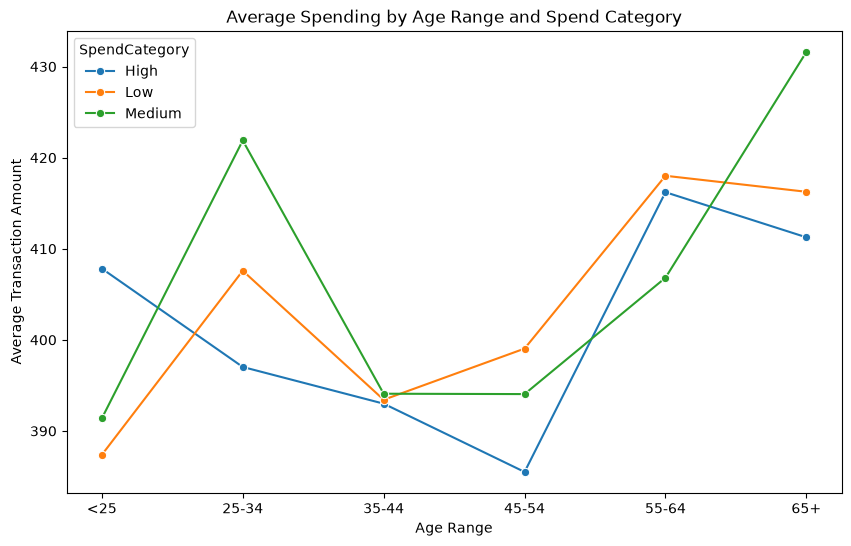

In [20]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=age_spend,
    x="AgeRange",
    y="TransactionAmount",
    hue="SpendCategory",
    marker="o"
)

plt.title("Average Spending by Age Range and Spend Category")
plt.xlabel("Age Range")
plt.ylabel("Average Transaction Amount")

plt.show()

### The same pattern appears across age groups.

- There is no consistent relationship between the `SpendCategory` label and average transaction amount by age.
- Based on the analyses above, I cannot determine exactly what `SpendCategory` represents, but it does **not appear to be directly calculated from transaction amount, product category, or age group**.


### SpendCategory conclusion

Across the distribution, product-category, and age-group checks, the High, Medium, and Low labels do not show the transaction-amount pattern I would expect if they were direct spending tiers. It is therefore not usable for my needs and **can be dropped** 


## Returning Customers

- Let's visualize the returning customers to see if there are any trends.


In [21]:
customer_visits = (
    df.groupby("CustomerID")
      .size()
      .reset_index(name="VisitCount")
)

returning_customers = customer_visits[
    customer_visits["VisitCount"] > 1
].copy()

returning_customers["ReturnCount"] = (
    returning_customers["VisitCount"] - 1
)

returning_customers.head()

,CustomerID,VisitCount,ReturnCount
37,10421,2,1
52,10623,2,1
56,10657,2,1
73,10774,2,1
148,11418,2,1


In [22]:
# Make buckets for visualization

return_buckets = (
    returning_customers
    .groupby("ReturnCount")
    .size()
    .reset_index(name="CustomerCount")
)

returning_rate = (
    len(returning_customers) / df["CustomerID"].nunique() * 100
)

print(f"Returning customers: {returning_rate:.2f}% of unique customers")
return_buckets


Returning customers: 5.34% of unique customers


,ReturnCount,CustomerCount
0,1,486
1,2,19
2,3,1


## Returning-customer summary

- Returning customers make up only about 5% of unique customers.
- Most returning customers made only one additional transaction.
- Very few customers returned more than once.

The grouped table communicates this pattern clearly, so an additional chart is not necessary here.


# Interactive chart

In [24]:
import plotly.express as px

age_spending = (
    df.groupby("AgeRange", observed=True)
      .agg(
          AverageSpending=("TransactionAmount", "mean"),
          Customers=("CustomerID", "nunique"),
          Transactions=("TransactionAmount", "size")
      )
      .reset_index()
)

age_spending

,AgeRange,AverageSpending,Customers,Transactions
0,<25,395.907092,1319,1329
1,25-34,408.676713,1871,1884
2,35-44,393.521948,1923,1950
3,45-54,393.079191,1927,1947
4,55-64,413.676790,1886,1902
5,65+,419.772775,983,988


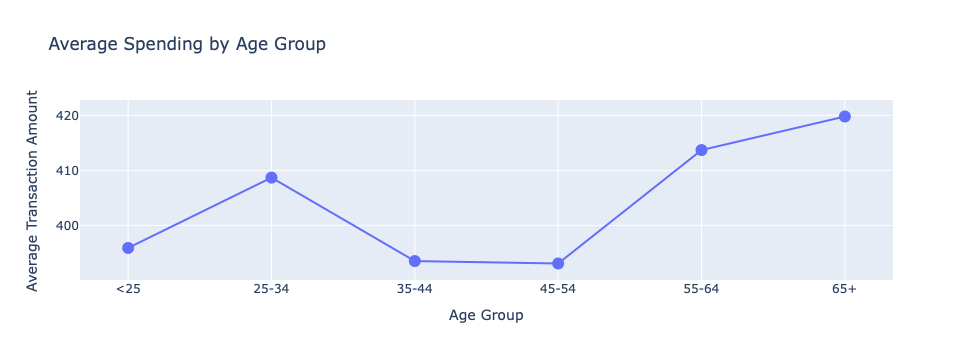

In [33]:
fig = px.line(
    age_spending,
    x="AgeRange",
    y="AverageSpending",
    markers=True,
    title="Average Spending by Age Group",
    labels={
        "AgeRange": "Age Group",
        "AverageSpending": "Average Transaction Amount"
    },
    custom_data=["Customers", "Transactions"]
)

fig.update_traces(
    marker=dict(size=12),
    
)

fig.show()

From this chart, the 55–64 and 65+ groups have the highest average transaction amounts, while the 35–54 groups are somewhat lower.

- The 65+ group (which only extends to age 69 in this dataset) also has far fewer transactions than the other age groups.
- Average transaction amount is the better measure for comparing spending behavior across age groups because it is not driven directly by how many transactions are in each group.
- I will also view **total spending** by age group, but that chart should be interpreted as each group's overall contribution to sales, not as a fair comparison of how much an individual customer tends to spend.


In [26]:
import plotly.express as px

age_total_spending = (
    df.groupby("AgeRange", observed=True)
      .agg(
          TotalSpending=("TransactionAmount", "sum"),
          Customers=("CustomerID", "nunique")
      )
      .reset_index()
)

age_total_spending

,AgeRange,TotalSpending,Customers
0,<25,526160.525830,1319
1,25-34,769946.926975,1871
2,35-44,767367.798956,1923
3,45-54,765325.184592,1927
4,55-64,786813.255483,1886
5,65+,414735.501723,983


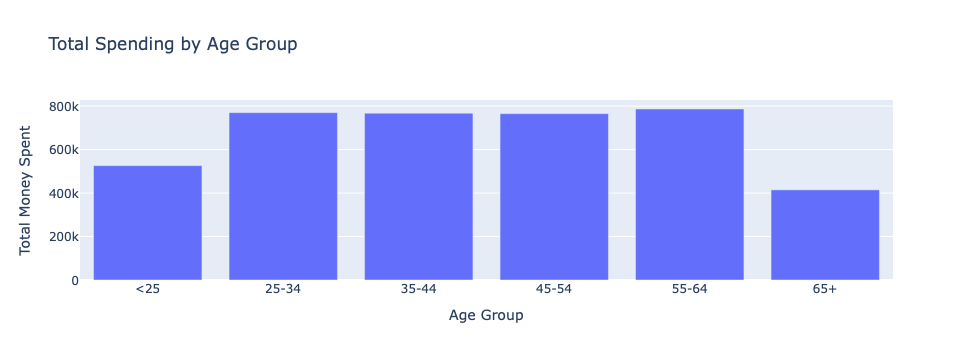

In [35]:
fig = px.bar(
    age_total_spending,
    x="AgeRange",
    y="TotalSpending",
    title="Total Spending by Age Group",
    labels={
        "AgeRange": "Age Group",
        "TotalSpending": "Total Money Spent"
    },
    custom_data=["Customers"]
)

fig.show()

The total-spending chart shows a different question from the average-spending chart.

- Total spending is fairly similar across the 25–64 groups.
- The 65+ group contributes much less total spending, largely because it contains far fewer transactions and customers.
- This does **not** contradict the fact that the 65+ group has the highest average transaction amount. It simply shows that a smaller group can spend more per transaction while still contributing less total revenue overall.


# Final notes: 

1) SepndCategory can be dropped, since its either wrong or has an undefined metric. 
2) There are less than 5% returning customers and they mostly came back only once. 
3) All ProductCategories seem to have the same spending distrubution. 
4) All age groups except oldest and youngest sepnt the same amount. 
5) 65-69 have the highest avg spending, but the least transactions. 